In [1]:
import ChessLens

from Dataset.DataSetLoaders import ChessDataset

import numpy as np
from matplotlib import pyplot as plt

from tqdm import tqdm

In [2]:
ds = ChessDataset.ChessDataset(
    root_dirs="/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1",
    config={
        "img_size": (640,640)
    },
    force_build_pkl=True
)

'/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1/Images/image_0.jpg'

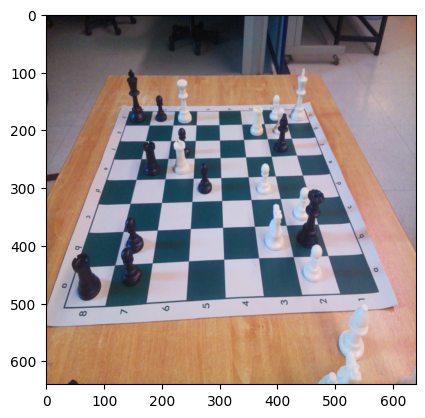

In [3]:
img, y = ds[0]

plt.imshow(img.permute(1,2,0));
y["image_path"]

'/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1/Images/image_0.jpg'

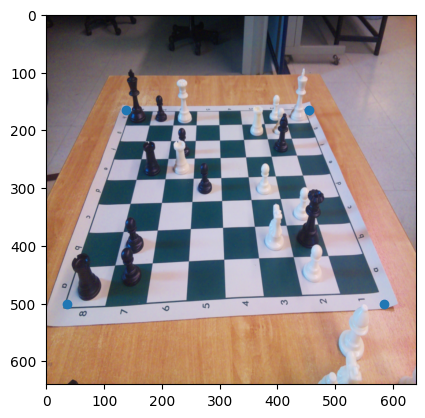

In [4]:
img = ChessLens.ChessLensImage(img)
img.detect_board()

plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);
img.board_detection.reshape(-1).to(int).tolist()

y["image_path"]

In [5]:
res = []

for i in tqdm(range(len(ds))):
    try:
        img, y = ds[i]

        img = ChessLens.ChessLensImage(img)
        img.detect_board()

        tmp = img.board_detection
        tmp[:,1] *= 480/640
        res.append(f"{y["image_path"]}:{",".join(map(lambda x: str(x), tmp.reshape(-1).to(int).tolist()))}")
    except:
        res.append(f"{y["image_path"]}:{",".join(["0"]*8)}")

        print(f"Image Failed at {y["image_path"]}")

res

100%|██████████| 50/50 [00:10<00:00,  4.95it/s]


['/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1/Images/image_0.jpg:138,123,455,123,584,375,35,375',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1/Images/image_1.jpg:134,120,461,120,578,366,40,375',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1/Images/image_2.jpg:141,120,454,120,580,375,36,375',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1/Images/image_3.jpg:135,123,457,123,585,378,33,378',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1/Images/image_4.jpg:178,120,498,124,617,381,82,363',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1/Images/image_5.jpg:176,120,498,125,616,381,85,365',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1/Images/image_6.jpg:179,123,493,123,619,384,78,371',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1/Images/image_7.jpg:179,120,501,126,620,384,78,371',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset1/Images/image_8.jpg:169,129,490,123,618,384,70,372',
 '/mnt/D/University/Thesis_Dataset/Pi

In [7]:
with open("tmp.txt", "w") as f:
    f.write("\n".join(res))

# Testing

In [31]:
i = 50

93 /mnt/D/University/Thesis_Dataset/Phone_Angles_Dataset/game2/image_23.jpg
tensor([[191.0000,  93.3333],
        [469.0000, 104.0000],
        [603.0000, 508.0000],
        [105.0000, 494.6667]])


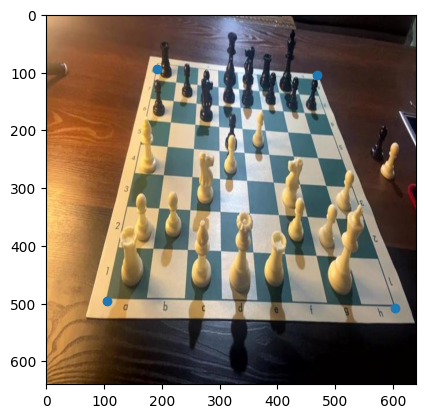

In [75]:
img, y = ds[i]

plt.imshow(img.permute(1,2,0));
plt.scatter(y["corners"][:,0], y["corners"][:,1]);

print(i, y["image_path"])
print(y["corners"])
i += 1